# Ising and Potts updates

I build one local Monte Carlo update before repeating it. The square lattice is periodic. In the Ising model a spin has value -1 or +1; the dimensionless interaction strength is one and temperature is measured in units of the interaction energy divided by Boltzmann’s constant. For Potts grain growth the integers identify grains, not compositions. Neighbor-copy proposals describe the supplied grain-growth kinetics and should not be presented as unbiased equilibrium sampling.

I write one part, test it, then continue. Run the cells in order. This short lesson checks the method; it does not replace the complete simulation or establish convergence.

**Using my code.** I permit free noncommercial teaching, learning and demonstrations with acknowledgment. Research (including academic research) and commercial use require my explicit written permission. Earlier MIT and GPL releases retain their existing permissions. Read the [code-use terms](https://saswataiith.github.io/files/CODE-USE-TERMS.txt). Request permission at saswata_at_msme.iith.ac.in. These terms apply to code; teaching text and figures have separate terms.


## 1. Inspect periodic neighbors

I first test the boundary indexing on a grid of known values. Opposite edges are adjacent. Rows and columns identify sites; they are dimensionless indices.

In [1]:
import numpy as np
rng = np.random.default_rng(7)
def neighbor_values(state, row, column):
    rows, columns = state.shape
    return [state[(row + 1) % rows, column], state[(row - 1) % rows, column],
            state[row, (column + 1) % columns], state[row, (column - 1) % columns]]

test_grid = np.arange(9).reshape(3, 3)
assert neighbor_values(test_grid, 0, 0) == [3, 6, 1, 2]
print("Periodic neighbor indexing passed.")

Periodic neighbor indexing passed.


## 2. Calculate the Ising energy change

Flipping a spin changes each of its four bond energies. In a uniform positive-spin neighborhood the change is +8. I check this before using a probability rule.

In [2]:
def ising_energy_change(old_spin, neighbors):
    return 2 * old_spin * sum(neighbors)

assert ising_energy_change(1, [1, 1, 1, 1]) == 8
assert ising_energy_change(-1, [1, 1, 1, 1]) == -8
print("Ising energy changes passed.")

Ising energy changes passed.


## 3. Accept or reject a trial

I always accept a decrease in energy. For an increase I accept with probability exp(-ΔE/T). The dimensionless temperature T must be positive in this implementation. This rule permits occasional uphill moves; energy need not decrease at every update.

In [3]:
def accept_trial(energy_change, temperature, rng):
    if temperature <= 0:
        raise ValueError("Use positive temperature in this example.")
    if energy_change <= 0:
        return True
    return rng.random() < np.exp(-energy_change / temperature)

assert accept_trial(-8, 1.5, rng)
assert accept_trial(0, 1.5, rng)
assert 0 < np.exp(-8 / 1.5) < 1
print("Acceptance checks passed.")

Acceptance checks passed.


## 4. Make and repeat one Ising trial

I choose a random site with replacement. One sweep consists of as many attempted updates as there are sites, so some sites can be chosen more than once. A spin flip does not conserve total spin.

In [4]:
def ising_trial(state, temperature, rng):
    row = rng.integers(state.shape[0])
    column = rng.integers(state.shape[1])
    old = state[row, column]
    change = ising_energy_change(old, neighbor_values(state, row, column))
    if accept_trial(change, temperature, rng):
        state[row, column] = -old

spins = rng.choice([-1, 1], (16, 16))
for trial in range(spins.size * 10):
    ising_trial(spins, 1.5, rng)
assert set(np.unique(spins)) <= {-1, 1}
print("Ising state values:", np.unique(spins))

Ising state values: [-1  1]


## 5. Change the local rule for Potts grain growth

For a Potts trial I propose a neighbor’s label and count unlike neighbors before and after the change. The energy change is the difference in these counts, in units of the grain-boundary interaction. No new grain label can be created by copying a neighbor. I check both the local change and that property.

Grains initially: 256 remaining labels: 30


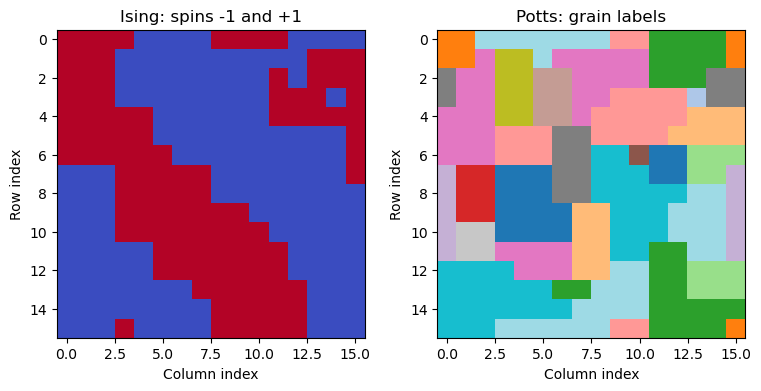

In [5]:
def potts_energy_change(old, candidate, neighbors):
    before = sum(value != old for value in neighbors)
    after = sum(value != candidate for value in neighbors)
    return after - before

assert potts_energy_change(1, 2, [2, 2, 2, 1]) == -2

def potts_trial(state, temperature, rng):
    row = rng.integers(state.shape[0])
    column = rng.integers(state.shape[1])
    neighbors = neighbor_values(state, row, column)
    candidate = neighbors[rng.integers(4)]
    change = potts_energy_change(state[row, column], candidate, neighbors)
    if accept_trial(change, temperature, rng):
        state[row, column] = candidate

grains = rng.permutation(np.arange(1, 257)).reshape(16, 16)
initial_labels = set(grains.ravel())
for trial in range(grains.size * 10):
    potts_trial(grains, 0.3, rng)
assert set(grains.ravel()) <= initial_labels
print("Grains initially:", len(initial_labels), "remaining labels:", len(np.unique(grains)))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(spins, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Ising: spins -1 and +1")
axes[1].imshow(grains, cmap="tab20")
axes[1].set_title("Potts: grain labels")
for ax in axes:
    ax.set_xlabel("Column index")
    ax.set_ylabel("Row index")
plt.show()

## Continue with the complete program

The original complete program is `../monte_carlo.py`. Its parameters, source credits and output commands are retained. These short examples use smaller workloads for learning; they are not a rerun of every result on the website.